# Mycosis Fungoides (MF) — Multi-Task Prediction Model
**Tasks:**
1. **Task 1 — Diagnosis:** Predict MF vs Non-MF
2. **Task 2 — Stage of MF:** Predict Patch-Plaque vs Tumor *(MF patients only)*
3. **Task 3 — Visit Type:** Predict New / FU / Rec *(All Patients)*

**Models:** XGBoost (primary) | Random Forest | Logistic Regression (benchmarks)

**Key Metrics:** Precision · Sensitivity (Recall) · F2-Score · ROC-AUC

## 0 — Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    precision_score, recall_score, fbeta_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, roc_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier
import shap

# ── reproducibility
SEED = 42
np.random.seed(SEED)

# ── plotting style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = sns.color_palette('tab10')

print('All imports OK')

All imports OK


## 1 — Load Data

In [2]:
FILE = 'X-cell MF 1 without test .xlsx'

# The file has 2 header rows: row 0 = group label, row 1 = actual column names.
# We read with header=[0,1] then flatten to the second-level names,
# preserving duplicate names by appending a numeric suffix.
raw = pd.read_excel(FILE, header=[0, 1], index_col=None)

# Flatten MultiIndex columns — keep only the second level (actual headers)
# and deduplicate by appending _2 for the second occurrence.
seen = {}
flat_cols = []
for col in raw.columns:
    name = str(col[1]).strip()
    seen[name] = seen.get(name, 0) + 1
    if seen[name] == 1:
        flat_cols.append(name)
    else:
        flat_cols.append(f"{name}_{seen[name]}")

raw.columns = flat_cols

# Drop the first row if it duplicated header text (common with merged cells)
if raw.iloc[0].astype(str).str.lower().isin(['patient data', 'age', 'sex']).sum() > 3:
    raw = raw.iloc[1:].reset_index(drop=True)

print(f'Shape: {raw.shape}')
print('Columns:', raw.columns.tolist())
raw.head(3)

Shape: (499, 35)
Columns: ['Patient Data', 'Age', 'Sex', 'no. of bx', 'Diagnosis', 'Duration', 'Course', 'New, FU, Rec', 'Prev. TTT', 'Type of TTT', 'Current TTT', 'Type of current TTT', 'Symptomatic', 'Symptoms', 'Head and Neck', 'UL', 'LL', 'Trunk', 'Buttocks', 'of BX 1 site', 'of BX 2 site', 'of BX 1 morph', 'of BX 2 morph', 'Stage of MF', 'color', 'Macules', 'Patch', 'Papules', 'Plaque', 'nodule', 'others', 'scales', 'others_2', 'Type of MF', 'Type of MF.1']


,Patient Data,Age,Sex,no. of bx,Diagnosis,Duration,Course,"New, FU, Rec",Prev. TTT,Type of TTT,...,Macules,Patch,Papules,Plaque,nodule,others,scales,others_2,Type of MF,Type of MF.1
0,magdy ahmed,62,male,36\5-25,MF,10 Y,progressive,New,no,NaN,...,no,yes,no,yes,no,no,yes,no,Classic MF,NaN
1,swzy shoker,64,female,19\5-25,PL- spectrum,1 M,progressive,New,yes,biologics (ps),...,yes,yes,yes,no,no,no,yes,no,NaN,NaN
2,Amr mohamed,33,male,39\5-25,MF,2 Y,progressive,Rec,yes,PUVA,...,no,yes,no,no,no,no,yes,no,Classic MF,NaN


## 2 — Column Renaming & Drop

In [3]:
# ── Canonical rename map  (adjust keys to match your actual flat column names)
RENAME = {
    'Patient Data': 'patient_id',
    'Age'         : 'age',
    'Sex'         : 'sex',
    'no. of bx'   : 'num_bx',
    'Diagnosis'   : 'diagnosis',
    'Duration'    : 'duration_raw',
    'Course'      : 'course',
    'New, FU, Rec': 'visit_type',
    'Prev. TTT'   : 'prev_ttt',
    'Type of TTT' : 'type_ttt',
    'Current TTT' : 'current_ttt',
    'Type of current TTT': 'type_current_ttt',
    'Symptomatic' : 'symptomatic',
    'Symptoms'    : 'symptoms',
    'Head and Neck': 'site_head_neck',
    'UL'          : 'site_ul',
    'LL'          : 'site_ll',
    'Trunk'       : 'site_trunk',
    'Buttocks'    : 'site_buttocks',
    'of BX 1 site': 'bx1_site',
    'of BX 2 site': 'bx2_site',
    'of BX 1 morph': 'bx1_morph',
    'of BX 2 morph': 'bx2_morph',
    'Stage of MF' : 'stage_mf',
    'color'       : 'color',
    'Macules '    : 'macules',
    ' Patch '     : 'patch',
    'Papules '    : 'papules',
    'Plaque'      : 'plaque',
    'nodule'      : 'nodule',
    'others'      : 'others',
    'others_2'    : 'others_2',
    'scales'      : 'scales',
    'Type of MF'  : 'type_mf',
}

# Strip trailing/leading spaces from all column names before renaming
raw.columns = [c.strip() for c in raw.columns]
raw = raw.rename(columns={k.strip(): v for k, v in RENAME.items()})

# ── Columns to drop as specified
DROP_COLS = ['prev_ttt', 'type_ttt', 'type_current_ttt', 'type_mf',
             'others', 'others_2', 'patient_id', 'Type of MF.1', 'symptoms', 'num_bx', 'current_ttt']
raw.drop(columns=[c for c in DROP_COLS if c in raw.columns], inplace=True)

print('Remaining columns:', raw.columns.tolist())
print('Shape:', raw.shape)

Remaining columns: ['age', 'sex', 'diagnosis', 'duration_raw', 'course', 'visit_type', 'symptomatic', 'site_head_neck', 'site_ul', 'site_ll', 'site_trunk', 'site_buttocks', 'bx1_site', 'bx2_site', 'bx1_morph', 'bx2_morph', 'stage_mf', 'color', 'macules', 'patch', 'papules', 'plaque', 'nodule', 'scales']
Shape: (499, 24)


## 3 — Preprocessing

In [5]:
df = raw.copy()

# ──────────────────────────────────────────────
# 3.1  Duration  →  numeric (months)
# ──────────────────────────────────────────────
def parse_duration(val):
    """Convert '10 Y', '6 M', '2 W', n\\a, NaN → float months."""
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower().replace('\\', '').replace('/', '')
    if s in ('na', 'n/a', 'na', ''):
        return np.nan
    # Extract the leading number and the unit letter
    m = re.match(r'([\d\.]+)\s*([ymwdYMWD])', s)
    if not m:
        # fallback: try to parse any number
        nums = re.findall(r'[\d\.]+', s)
        return float(nums[0]) if nums else np.nan
    num, unit = float(m.group(1)), m.group(2)
    return {'y': num * 12, 'm': num, 'w': num / 4.33, 'd': num / 30}.get(unit, np.nan)

df['duration_months'] = df['duration_raw'].apply(parse_duration)
df.drop(columns=['duration_raw'], inplace=True)

# ──────────────────────────────────────────────
# 3.2  Normalise free-text fields
# ──────────────────────────────────────────────
def norm(s, mapping=None):
    """Lowercase, strip, optional remap."""
    if pd.isna(s):
        return np.nan
    s = str(s).strip().lower()
    if mapping:
        for pat, rep in mapping.items():
            if re.fullmatch(pat, s):
                return rep
    return s

# diagnosis → binary MF / Non-MF
df['diagnosis_raw'] = df['diagnosis'].copy()
df['diagnosis'] = df['diagnosis'].apply(
    lambda x: 'MF' if norm(x) == 'mf' else 'Non-MF'
)

# df['current_ttt'] = df['current_ttt'].fillna('no')
# df['current_ttt'] = df['current_ttt'].apply(lambda x: 'no' if str(x).strip().lower() in ('n/a', 'na', 'nan', '') else str(x).strip().lower())

# Treat the absence of a second biopsy as its own clinical category
df['bx2_site'] = df['bx2_site'].fillna('no_bx_site')
df['bx2_morph'] = df['bx2_morph'].fillna('no_bx_morph')

df['bx1_site'] = df['bx1_site'].fillna('no_bx_site')
df['bx1_morph'] = df['bx1_morph'].fillna('no_bx_morph')

# stage_mf  → Patch-Plaque / Tumor / nan
STAGE_MAP = {
    r'patch.*plaque|patch-plaque|pp': 'Patch-Plaque',
    r'tumor|tumour':                  'Tumor',
    r'n/?a':                          np.nan,
}
def map_stage(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().lower()
    for pat, val in STAGE_MAP.items():
        if re.fullmatch(pat, s):
            return val
    return np.nan

df['stage_mf'] = df['stage_mf'].apply(map_stage)

# visit_type → New / FU / Rec
VISIT_MAP = {r'new': 'New', r'fu|follow.?up': 'FU', r'rec|recurrent': 'Rec'}
def map_visit(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().lower()
    for pat, val in VISIT_MAP.items():
        if re.fullmatch(pat, s):
            return val
    return np.nan

df['visit_type'] = df['visit_type'].apply(map_visit)

# course
df['course'] = df['course'].apply(lambda x: norm(x, {r'progressive': 'progressive',
                                                       r'stationary': 'stationary'}))

# bx site normalisation (buttocks / Buttocks)
for col in ['bx1_site', 'bx2_site']:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: norm(x, {
            r'buttocks?': 'buttocks', r'n/?a': np.nan
        }))

# bx morphology normalisation
for col in ['bx1_morph', 'bx2_morph']:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: norm(x, {r'n/?a': np.nan}))

# yes/no columns
YES_NO_COLS = ['site_head_neck', 'site_ul', 'site_ll', 'site_trunk',
               'site_buttocks', 'symptomatic', 'macules', 'patch',
               'papules', 'plaque', 'nodule', 'scales']
for col in YES_NO_COLS:
    if col in df.columns:
        df[col] = df[col].apply(
            lambda x: 1 if str(x).strip().lower() in ('yes','y') else
                      (0 if str(x).strip().lower() in ('no','n') else np.nan)
        )

# sex
df['sex'] = df['sex'].apply(lambda x: norm(x, {r'male|m': 'male', r'female|f': 'female'}))

# num_bx — extract first numeric part (e.g. "36\5-25" → 36)
if 'num_bx' in df.columns:
    df['num_bx'] = df['num_bx'].apply(
        lambda x: float(re.findall(r'[\d]+', str(x))[0])
        if re.findall(r'[\d]+', str(x)) else np.nan
    )

# age
df['age'] = pd.to_numeric(df['age'], errors='coerce')

print(df.dtypes)
df.head(3)

age                float64
sex                 object
diagnosis           object
course              object
visit_type          object
symptomatic          int64
site_head_neck     float64
site_ul            float64
site_ll            float64
site_trunk         float64
site_buttocks        int64
bx1_site            object
bx2_site            object
bx1_morph           object
bx2_morph           object
stage_mf            object
color               object
macules              int64
patch                int64
papules              int64
plaque             float64
nodule               int64
scales               int64
duration_months    float64
diagnosis_raw       object
dtype: object


,age,sex,diagnosis,course,visit_type,symptomatic,site_head_neck,site_ul,site_ll,site_trunk,...,stage_mf,color,macules,patch,papules,plaque,nodule,scales,duration_months,diagnosis_raw
0,62.0,male,MF,progressive,New,1,1.0,1.0,1.0,1.0,...,Patch-Plaque,erythematous,0,1,0,1.0,0,1,120.0,MF
1,64.0,female,Non-MF,progressive,New,1,0.0,0.0,1.0,1.0,...,NaN,hypopigmented,1,1,1,0.0,0,1,1.0,PL- spectrum
2,33.0,male,MF,progressive,Rec,0,0.0,0.0,1.0,1.0,...,Patch-Plaque,erythematous,0,1,0,0.0,0,1,24.0,MF


In [6]:
# ──────────────────────────────────────────────
# 3.3  Encode categorical features
# ──────────────────────────────────────────────
CAT_COLS = ['sex', 'course', 'symptoms', 'color',
            'bx1_site', 'bx2_site', 'bx1_morph', 'bx2_morph', 'current_ttt']
CAT_COLS = [c for c in CAT_COLS if c in df.columns]

encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    non_null = df[col].notna()
    df.loc[non_null, col] = le.fit_transform(df.loc[non_null, col].astype(str))
    df[col] = pd.to_numeric(df[col], errors='coerce')
    encoders[col] = le

print('Encoding done. Sample value counts for diagnosis:')
print(df['diagnosis'].value_counts())

Encoding done. Sample value counts for diagnosis:
diagnosis
MF        353
Non-MF    146
Name: count, dtype: int64


## 4 — EDA

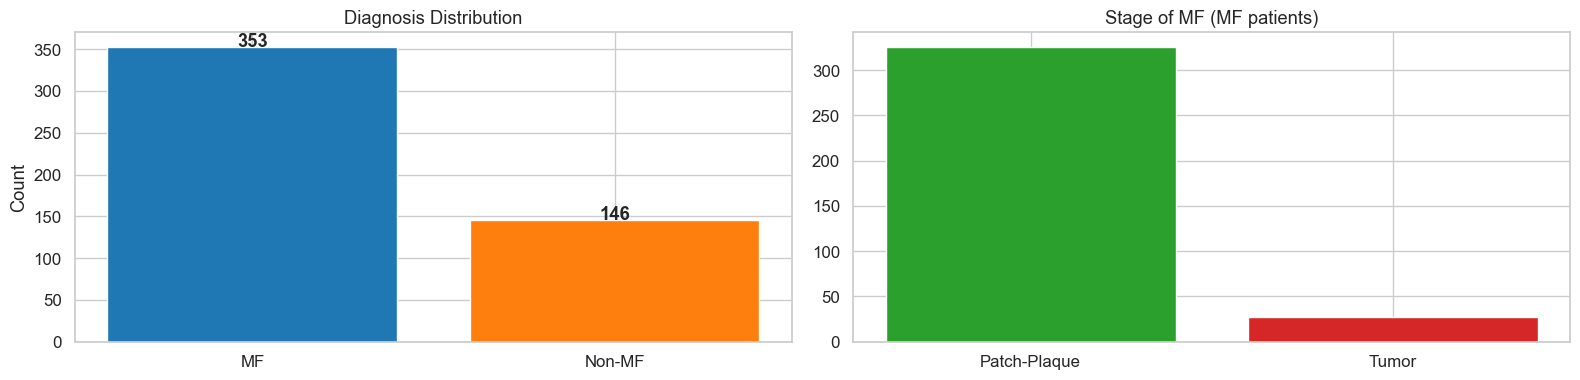

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Diagnosis distribution
vc = df['diagnosis'].value_counts()
axes[0].bar(vc.index, vc.values, color=COLORS[:len(vc)])
axes[0].set_title('Diagnosis Distribution')
axes[0].set_ylabel('Count')
for i, (idx, v) in enumerate(vc.items()):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Stage of MF (MF patients only)
mf_df = df[df['diagnosis'] == 'MF']
if 'stage_mf' in df.columns:
    vc2 = mf_df['stage_mf'].value_counts(dropna=False)
    axes[1].bar(vc2.index.astype(str), vc2.values, color=COLORS[2:2+len(vc2)])
    axes[1].set_title('Stage of MF (MF patients)')

# # Visit type
# vc3 = df['visit_type'].value_counts(dropna=False)
# axes[2].bar(vc3.index.astype(str), vc3.values, color=COLORS[4:4+len(vc3)])
# axes[2].set_title('Visit Type Distribution')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

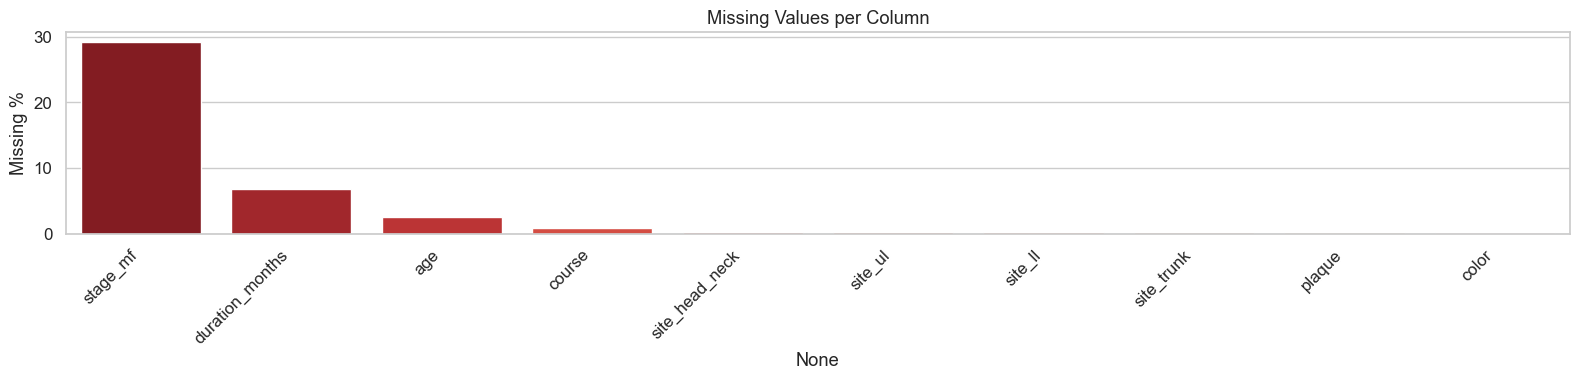

In [11]:
# Missing value heatmap
plt.figure(figsize=(16, 4))
miss = df.isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]
sns.barplot(x=miss.index, y=miss.values * 100, palette='Reds_r')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Missing %')
plt.title('Missing Values per Column')
plt.tight_layout()
plt.savefig('eda_missing.png', dpi=150, bbox_inches='tight')
plt.show()

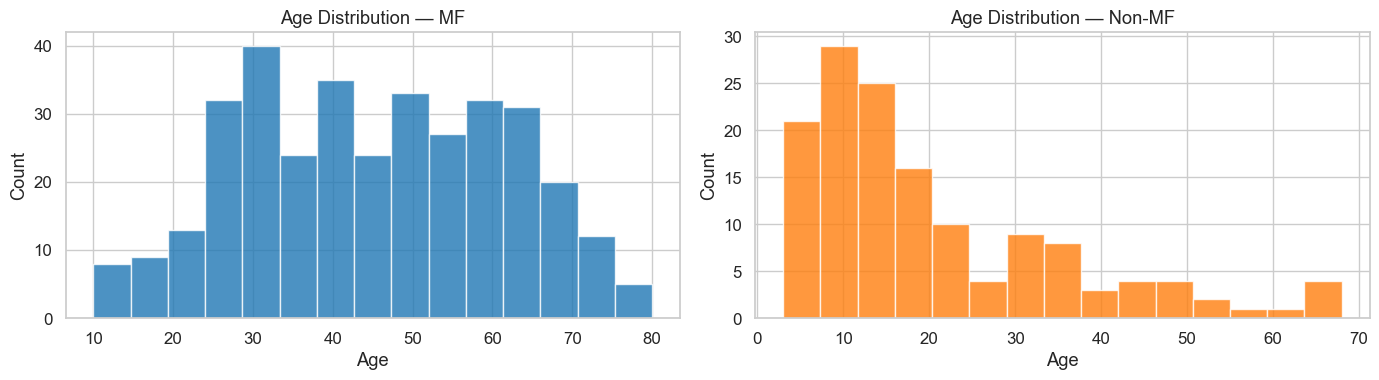

In [12]:
# Age distribution by diagnosis
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, grp in zip(axes, ['MF', 'Non-MF']):
    subset = df[df['diagnosis'] == grp]['age'].dropna()
    ax.hist(subset, bins=15, color=COLORS[0 if grp=='MF' else 1], alpha=0.8, edgecolor='white')
    ax.set_title(f'Age Distribution — {grp}')
    ax.set_xlabel('Age')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('eda_age.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — Helper Functions (Training & Evaluation)

In [13]:
from sklearn.base import clone

def make_models():
    """Return the three model objects."""
    xgb = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        random_state=SEED, n_jobs=-1, scale_pos_weight=12,
    )
    rf = RandomForestClassifier(
        n_estimators=300, max_depth=6,
        random_state=SEED, n_jobs=-1
    )
    lr = LogisticRegression(
        max_iter=1000, C=0.5, solver='lbfgs',
        random_state=SEED
    )
    return {'XGBoost': xgb, 'Random Forest': rf, 'Logistic Regression': lr}

# Define the 16 selected features
SELECT_FEATURES = [
    'macules', 'bx1_morph', 'papules', 'age', 'color', 'patch',
    'bx2_morph', 'visit_type', 'duration_months', 'plaque', 'scales',
    'site_head_neck', 'site_ll', 'course', 'bx2_site', 'nodule'
]

def prepare_xy(data, target_col, drop_targets):
    """Split features / labels, use only SELECT_FEATURES."""
    y = data[target_col].copy()
    # Use only the 16 selected features that exist in the data
    available_features = [f for f in SELECT_FEATURES if f in data.columns]
    X = data[available_features].copy()
    X = X.select_dtypes(include=[np.number])  # keep numeric only
    return X, y


def evaluate_binary(model, X, y, model_name, task_name, n_splits=5):
    """
    Stratified k-fold evaluation for binary classification.
    Returns dict of mean metrics.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    prec, rec, f2, auc = [], [], [], []

    for train_idx, test_idx in skf.split(X, y_enc):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y_enc[train_idx], y_enc[test_idx]

        imp = SimpleImputer(strategy='median')
        X_tr = imp.fit_transform(X_tr)
        X_te = imp.transform(X_te)

        m = clone(model)
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_te)
        y_prob = m.predict_proba(X_te)[:, 1] if hasattr(m, 'predict_proba') else y_pred

        prec.append(precision_score(y_te, y_pred, zero_division=0))
        rec.append(recall_score(y_te, y_pred, zero_division=0))
        f2.append(fbeta_score(y_te, y_pred, beta=2, zero_division=0))
        try:
            auc.append(roc_auc_score(y_te, y_prob))
        except:
            auc.append(np.nan)

    return {
        'Model': model_name, 'Task': task_name,
        'Precision': np.mean(prec),
        'Sensitivity': np.mean(rec),
        'F2-Score': np.mean(f2),
        'ROC-AUC': np.mean(auc),
    }


def evaluate_multiclass(model, X, y, model_name, task_name, n_splits=5):
    """Stratified k-fold for multiclass (macro averages)."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    classes = le.classes_

    prec, rec, f2, auc = [], [], [], []

    for train_idx, test_idx in skf.split(X, y_enc):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y_enc[train_idx], y_enc[test_idx]

        imp = SimpleImputer(strategy='median')
        X_tr = imp.fit_transform(X_tr)
        X_te = imp.transform(X_te)

        m = clone(model)
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_te)

        prec.append(precision_score(y_te, y_pred, average='macro', zero_division=0))
        rec.append(recall_score(y_te, y_pred, average='macro', zero_division=0))
        f2.append(fbeta_score(y_te, y_pred, beta=2, average='macro', zero_division=0))

        if hasattr(m, 'predict_proba') and len(classes) > 1:
            y_prob = m.predict_proba(X_te)
            try:
                auc.append(roc_auc_score(
                    label_binarize(y_te, classes=np.arange(len(classes))),
                    y_prob, multi_class='ovr', average='macro'
                ))
            except:
                auc.append(np.nan)
        else:
            auc.append(np.nan)

    return {
        'Model': model_name, 'Task': task_name,
        'Precision': np.mean(prec),
        'Sensitivity': np.mean(rec),
        'F2-Score': np.mean(f2),
        'ROC-AUC': np.mean(auc),
    }


print('Helper functions defined.')

Helper functions defined.


## 6 — Task 1: Diagnosis (MF vs Non-MF)

In [14]:
ALL_TARGETS = ['diagnosis', 'stage_mf']
MODELS = make_models()

# ── Build dataset
X1, y1 = prepare_xy(df, 'diagnosis', ALL_TARGETS)
valid1 = y1.notna()
X1, y1 = X1[valid1], y1[valid1]

print('Task 1 — class distribution:')
print(y1.value_counts())
print(f'Features: {X1.shape[1]}')

Task 1 — class distribution:
diagnosis
MF        353
Non-MF    146
Name: count, dtype: int64
Features: 15


In [15]:
results_t1 = []
for name, model in MODELS.items():
    r = evaluate_binary(model, X1, y1, name, 'Diagnosis (MF vs Non-MF)')
    results_t1.append(r)
    print(f"{name:20s} | Prec={r['Precision']:.3f}  Sens={r['Sensitivity']:.3f}  "
          f"F2={r['F2-Score']:.3f}  AUC={r['ROC-AUC']:.3f}")

XGBoost              | Prec=0.908  Sens=0.945  F2=0.937  AUC=0.994
Random Forest        | Prec=0.948  Sens=0.938  F2=0.939  AUC=0.995
Logistic Regression  | Prec=0.915  Sens=0.918  F2=0.916  AUC=0.985


## 7 — Task 2: Stage of MF (Patch-Plaque vs Tumor)

In [17]:
mf_only = df[df['diagnosis'] == 'MF'].copy()
X2, y2 = prepare_xy(mf_only, 'stage_mf', ALL_TARGETS)
valid2 = y2.notna()
X2, y2 = X2[valid2], y2[valid2]

print('Task 2 — class distribution:')
print(y2.value_counts())

results_t2 = []
for name, model in MODELS.items():
    r = evaluate_binary(model, X2, y2, name, 'Stage of MF')
    results_t2.append(r)
    print(f"{name:20s} | Prec={r['Precision']:.3f}  Sens={r['Sensitivity']:.3f}  "
          f"F2={r['F2-Score']:.3f}  AUC={r['ROC-AUC']:.3f}")

Task 2 — class distribution:
stage_mf
Patch-Plaque    326
Tumor            27
Name: count, dtype: int64
XGBoost              | Prec=0.828  Sens=0.860  F2=0.843  AUC=0.990
Random Forest        | Prec=0.870  Sens=0.860  F2=0.855  AUC=0.987
Logistic Regression  | Prec=0.700  Sens=0.527  F2=0.532  AUC=0.968


## 8 — Task 3: Visit Type (New / FU / Rec) — All Patients

In [ ]:
# X3, y3 = prepare_xy(df, 'visit_type', ALL_TARGETS)
# valid3 = y3.notna()
# X3, y3 = X3[valid3], y3[valid3]

# print('Task 3 — class distribution:')
# print(y3.value_counts())

# results_t3 = []
# for name, model in MODELS.items():
#     r = evaluate_multiclass(model, X3, y3, name, 'Visit Type (New/FU/Rec) — All Patients')
#     results_t3.append(r)
#     print(f"{name:20s} | Prec={r['Precision']:.3f}  Sens={r['Sensitivity']:.3f}  "
#           f"F2={r['F2-Score']:.3f}  AUC={r['ROC-AUC']:.3f}")

Task 3 — class distribution:
visit_type
New    322
FU     129
Rec     48
Name: count, dtype: int64
XGBoost              | Prec=0.743  Sens=0.637  F2=0.645  AUC=0.846
Random Forest        | Prec=0.844  Sens=0.513  F2=0.519  AUC=0.836
Logistic Regression  | Prec=0.582  Sens=0.502  F2=0.505  AUC=0.775


## 9 — Results Summary Table

In [ ]:
all_results = pd.DataFrame(results_t1 + results_t2)
all_results = all_results.round(3)

metric_cols = ['Precision', 'Sensitivity', 'F2-Score', 'ROC-AUC']

# Highlight best per task+metric
def highlight_max_per_task(data):
    # Create an empty DataFrame of the same shape to hold the CSS styles
    styles = pd.DataFrame('', index=data.index, columns=data.columns)
    
    # Loop through each unique Task ('Diagnosis (MF vs Non-MF)' and 'Stage of MF')
    for task in data['Task'].unique():
        task_idx = data.index[data['Task'] == task]
        
        # Loop through each metric column
        for col in metric_cols:
            # Find the max value for this specific task and column
            max_val = data.loc[task_idx, col].max()
            
            # Create a boolean mask of where the max values are
            is_max = data.loc[task_idx, col] == max_val
            
            # Apply the CSS style to those specific cells (added color: black)
            styles.loc[task_idx[is_max], col] = 'background-color: #d4edda; color: black; font-weight: bold'
            
    return styles

# Apply the styling
display(all_results.style
        .apply(highlight_max_per_task, axis=None)
        .format({m: '{:.3f}' for m in metric_cols})
        .set_caption('Cross-Validation Metrics (5-Fold Stratified)'))

,Model,Task,Precision,Sensitivity,F2-Score,ROC-AUC
0,XGBoost,Diagnosis (MF vs Non-MF),0.908,0.945,0.937,0.994
1,Random Forest,Diagnosis (MF vs Non-MF),0.948,0.938,0.939,0.995
2,Logistic Regression,Diagnosis (MF vs Non-MF),0.915,0.918,0.916,0.985
3,XGBoost,Stage of MF,0.828,0.860,0.843,0.990
4,Random Forest,Stage of MF,0.870,0.860,0.855,0.987
5,Logistic Regression,Stage of MF,0.700,0.527,0.532,0.968


## 10 — Visualisations

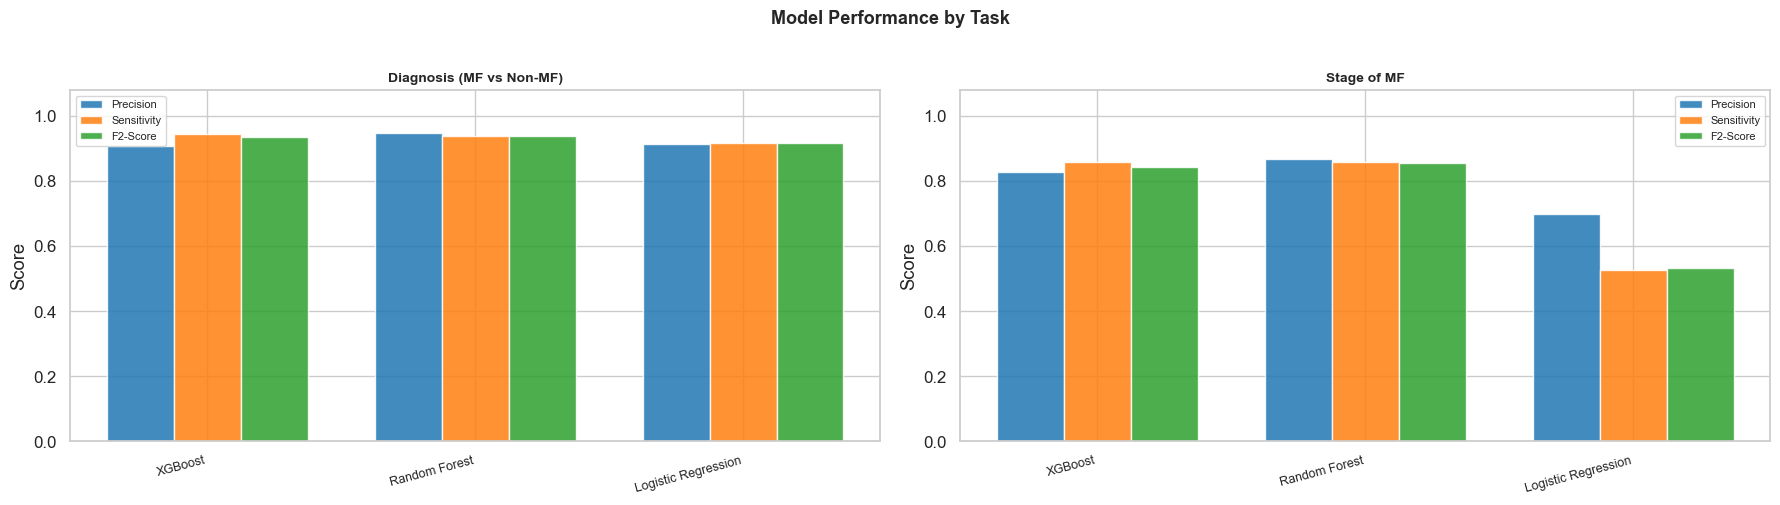

In [23]:
# ── 10.1  Grouped bar chart — F2-Score & Sensitivity across all tasks & models
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=False)
tasks_names = [
    'Diagnosis (MF vs Non-MF)',
    'Stage of MF'
]
all_task_results = [results_t1, results_t2]
x_pos = np.arange(3)
width = 0.25
model_names = list(MODELS.keys())

for ax, task_res, task_name in zip(axes, all_task_results, tasks_names):
    for i, metric in enumerate(['Precision', 'Sensitivity', 'F2-Score']):
        vals = [r[metric] for r in task_res]
        offset = (i - 1) * width
        bars = ax.bar(x_pos + offset, vals, width, label=metric,
                      color=COLORS[i], alpha=0.85, edgecolor='white')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, 1.08)
    ax.set_title(task_name, fontsize=10, fontweight='bold')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)

plt.suptitle('Model Performance by Task', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

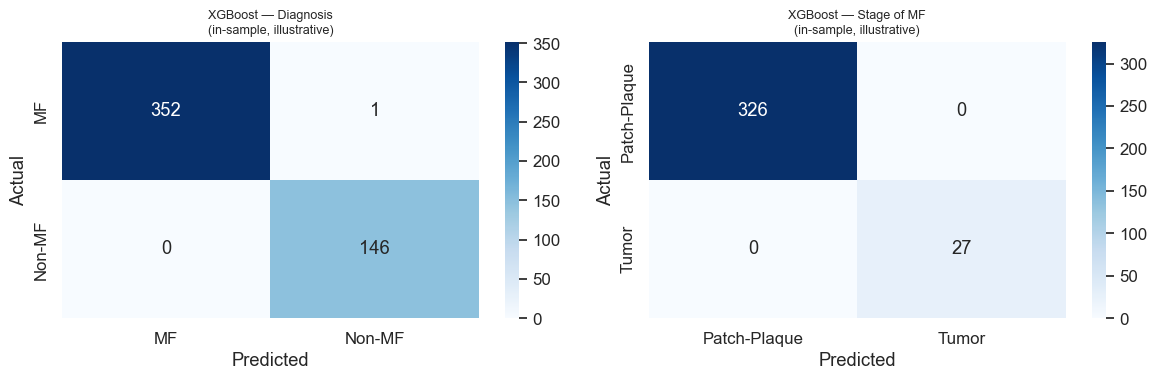

In [24]:
# ── 10.2  Confusion matrices — XGBoost on each task (final full-data fit)
def plot_cm(model, X, y, task_name, ax, le=None):
    imp = SimpleImputer(strategy='median')
    X_imp = imp.fit_transform(X)
    le_inner = LabelEncoder().fit(y)
    y_enc = le_inner.transform(y)
    model.fit(X_imp, y_enc)
    y_pred = model.predict(X_imp)
    cm = confusion_matrix(y_enc, y_pred)
    labels = le_inner.classes_
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f'XGBoost — {task_name}\n(in-sample, illustrative)', fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
xgb = MODELS['XGBoost']

from sklearn.base import clone
plot_cm(clone(xgb), X1, y1, 'Diagnosis', axes[0])
if len(y2) > 0:
    plot_cm(clone(xgb), X2, y2, 'Stage of MF', axes[1])

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

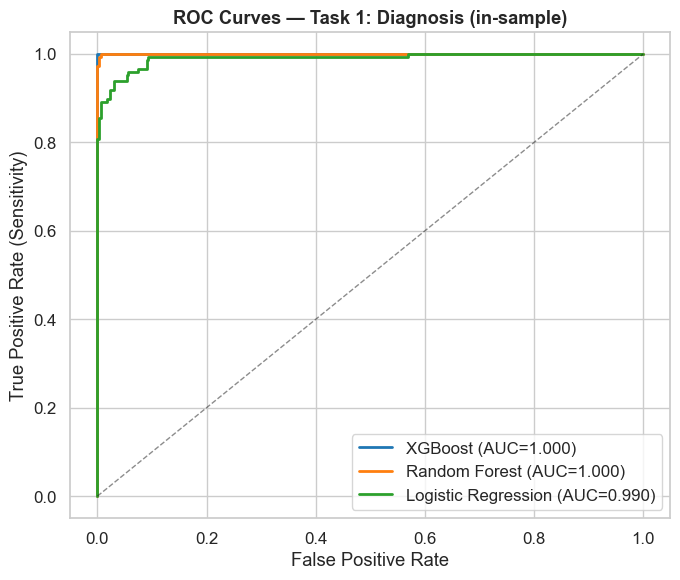

In [25]:
# ── 10.3  ROC Curves — Task 1 (binary), all three models
fig, ax = plt.subplots(figsize=(7, 6))

le_diag = LabelEncoder().fit(y1)
y1_enc = le_diag.transform(y1)
imp_diag = SimpleImputer(strategy='median').fit(X1)
X1_imp = imp_diag.transform(X1)

for i, (name, model) in enumerate(MODELS.items()):
    m = clone(model)
    m.fit(X1_imp, y1_enc)
    if hasattr(m, 'predict_proba'):
        y_prob = m.predict_proba(X1_imp)[:, 1]
    else:
        y_prob = m.decision_function(X1_imp)
    fpr, tpr, _ = roc_curve(y1_enc, y_prob)
    auc_val = roc_auc_score(y1_enc, y_prob)
    ax.plot(fpr, tpr, color=COLORS[i], lw=2,
            label=f'{name} (AUC={auc_val:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curves — Task 1: Diagnosis (in-sample)', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves_task1.png', dpi=150, bbox_inches='tight')
plt.show()

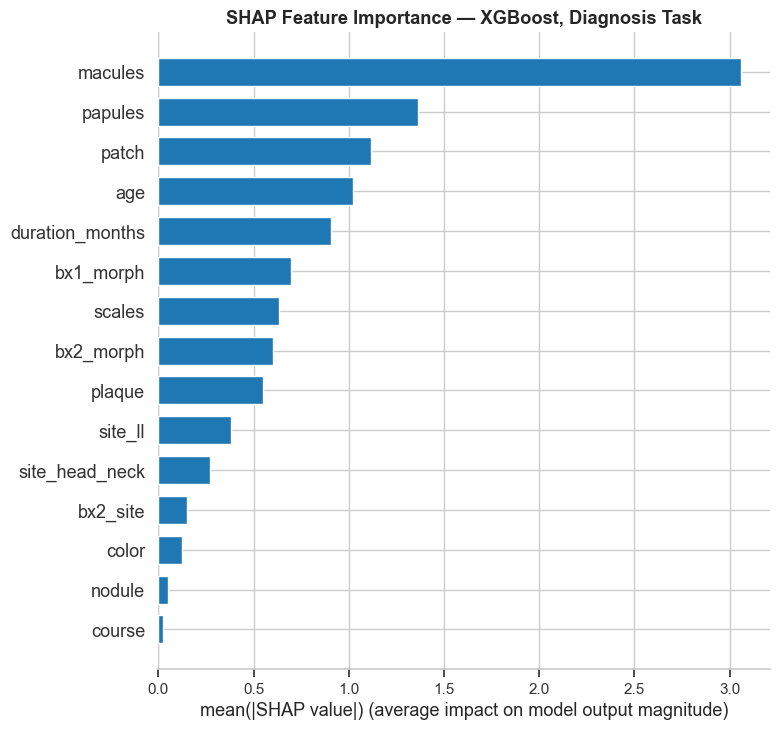

In [26]:
# ── 10.4  SHAP Feature Importance — XGBoost, Task 1
imp_shap = SimpleImputer(strategy='median').fit(X1)
X1_imp = imp_shap.transform(X1)
X1_imp_df = pd.DataFrame(X1_imp, columns=X1.columns)

le_diag = LabelEncoder().fit(y1)
xgb_fitted = clone(MODELS['XGBoost'])
xgb_fitted.fit(X1_imp, le_diag.transform(y1))

explainer = shap.TreeExplainer(xgb_fitted)
shap_values = explainer.shap_values(X1_imp_df)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X1_imp_df, plot_type='bar', show=False,
                  max_display=15, color=COLORS[0])
plt.title('SHAP Feature Importance — XGBoost, Diagnosis Task', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance_task1.png', dpi=150, bbox_inches='tight')
plt.show()

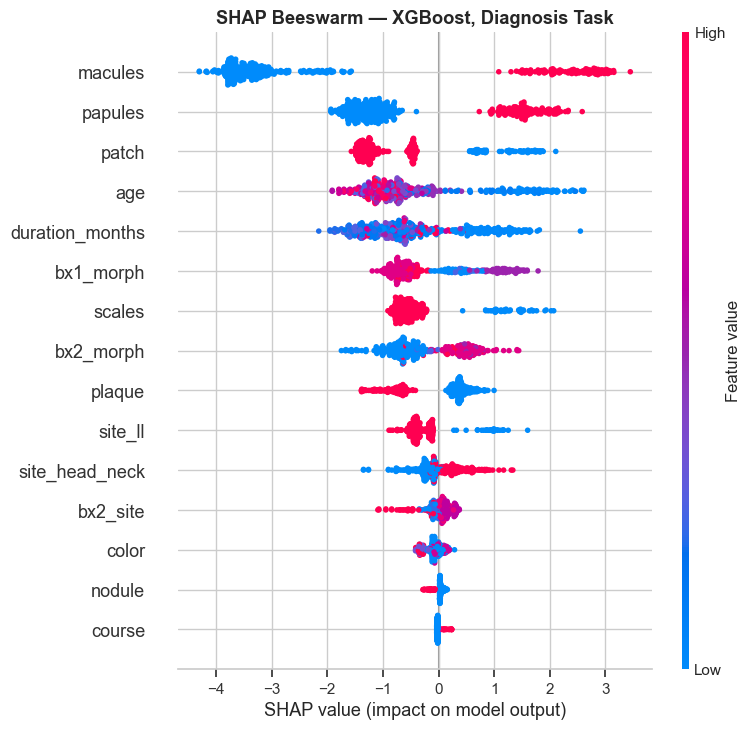

In [27]:
# ── 10.5  SHAP Beeswarm — Task 1
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X1_imp_df, show=False, max_display=15)
plt.title('SHAP Beeswarm — XGBoost, Diagnosis Task', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm_task1.png', dpi=150, bbox_inches='tight')
plt.show()

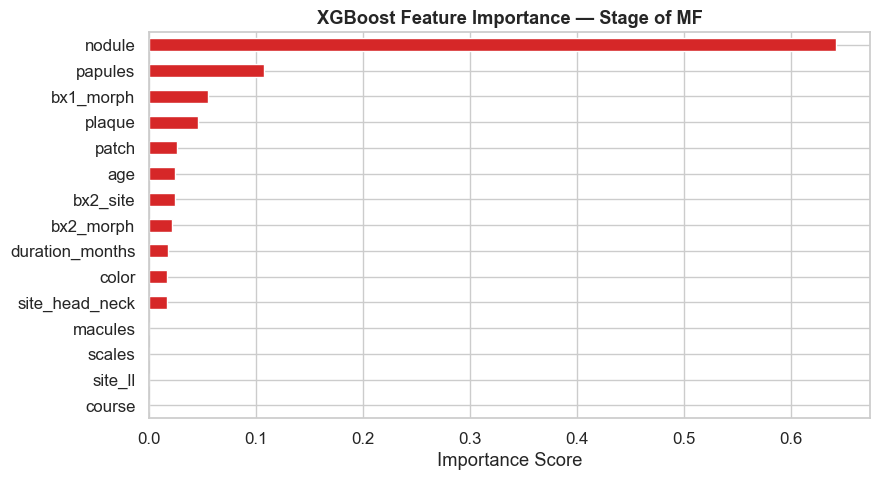

In [28]:
# ── 10.6  XGBoost feature importance — Tasks 2 & 3
for X_task, y_task, task_label in [
    (X2, y2, 'Stage of MF')
]:
    if len(y_task) == 0 or y_task.nunique() < 2:
        print(f'Skipping {task_label} — insufficient classes.')
        continue
    imp_t = SimpleImputer(strategy='median').fit(X_task)
    X_imp_t = imp_t.transform(X_task)
    X_imp_df = pd.DataFrame(X_imp_t, columns=X_task.columns)
    le_t = LabelEncoder().fit(y_task)
    xgb_t = clone(MODELS['XGBoost'])
    xgb_t.fit(X_imp_t, le_t.transform(y_task))

    fi = pd.Series(xgb_t.feature_importances_, index=X_task.columns)
    fi = fi.sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(9, 5))
    fi.plot.barh(ax=ax, color=COLORS[3], edgecolor='white')
    ax.invert_yaxis()
    ax.set_title(f'XGBoost Feature Importance — {task_label}', fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    fname = f'fi_{task_label.replace(" ","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

## 11 — Final Full-Data Training & Classification Reports

> **Note:** In-sample classification reports are shown below for completeness.  
> Cross-validation metrics (Section 6-8) are the reliable numbers for the paper.

In [29]:
def full_report(X, y, task_label, multiclass=False):
    imp = SimpleImputer(strategy='median')
    X_imp = imp.fit_transform(X)
    le = LabelEncoder().fit(y)
    y_enc = le.transform(y)
    print(f"\n{'='*60}")
    print(f'  TASK: {task_label}')
    print(f'  Classes: {le.classes_}')
    print(f"{'='*60}")
    for name, model in MODELS.items():
        m = clone(model)
        m.fit(X_imp, y_enc)
        y_pred = m.predict(X_imp)
        print(f'\n  [{name}]')
        print(classification_report(y_enc, y_pred,
                                    target_names=le.classes_.astype(str),
                                    zero_division=0))

full_report(X1, y1, 'Diagnosis (MF vs Non-MF)')
if len(y2) > 1: full_report(X2, y2, 'Stage of MF')


  TASK: Diagnosis (MF vs Non-MF)
  Classes: ['MF' 'Non-MF']

  [XGBoost]
              precision    recall  f1-score   support

          MF       1.00      1.00      1.00       353
      Non-MF       0.99      1.00      1.00       146

    accuracy                           1.00       499
   macro avg       1.00      1.00      1.00       499
weighted avg       1.00      1.00      1.00       499


  [Random Forest]
              precision    recall  f1-score   support

          MF       0.99      1.00      0.99       353
      Non-MF       0.99      0.98      0.99       146

    accuracy                           0.99       499
   macro avg       0.99      0.99      0.99       499
weighted avg       0.99      0.99      0.99       499


  [Logistic Regression]
              precision    recall  f1-score   support

          MF       0.97      0.97      0.97       353
      Non-MF       0.93      0.93      0.93       146

    accuracy                           0.96       499
   macro a

## 12 — Save Results CSV

In [30]:
all_results.to_csv('MF_model_results_selected_features.csv', index=False)
print('Results saved to MF_model_results_selected_features.csv')
print(all_results.to_string(index=False))

Results saved to MF_model_results_selected_features.csv
              Model                     Task  Precision  Sensitivity  F2-Score  ROC-AUC
            XGBoost Diagnosis (MF vs Non-MF)      0.908        0.945     0.937    0.994
      Random Forest Diagnosis (MF vs Non-MF)      0.948        0.938     0.939    0.995
Logistic Regression Diagnosis (MF vs Non-MF)      0.915        0.918     0.916    0.985
            XGBoost              Stage of MF      0.828        0.860     0.843    0.990
      Random Forest              Stage of MF      0.870        0.860     0.855    0.987
Logistic Regression              Stage of MF      0.700        0.527     0.532    0.968
